In [14]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc3 as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

In [15]:
gabor_params = {
    "canvas_size": [50, 50],
    "sizes": [15],  # 4xstd
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": [[25, 25]],
    "orientations": [np.pi / 2],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

center = GaborSet(**gabor_params)

(-0.5, 49.5, 49.5, -0.5)

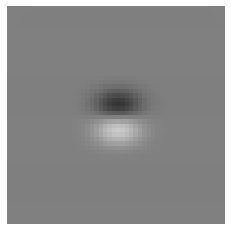

In [3]:
plt.imshow(center.images()[0], cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [ ]:
gabor_params = {
    "canvas_size": [50, 50],
    "sizes": [15],  # 4xstd
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": [[25, 25]],
    "orientations": [np.pi / 2],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

center = GaborSet(**gabor_params)

(-0.5, 49.5, 49.5, -0.5)

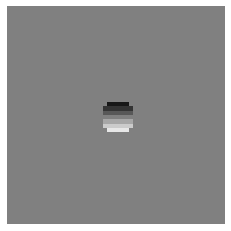

In [5]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 10],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0, np.pi / 2],
    "locations": [[25, 25]],
    "sizes_total": [15],
    "sizes_center": [15 / 50],
    "sizes_surround": [15 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [0],
}

center_cut = CenterSurround(**center_surround_params)

plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

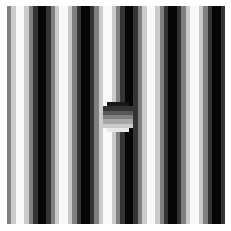

In [6]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 10],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_cut = CenterSurround(**center_surround_params)

plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

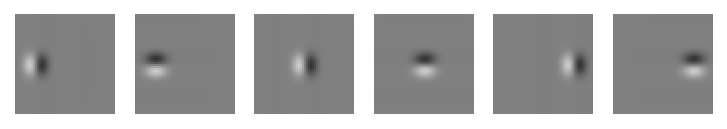

In [9]:
gabor_locations = [(10, 25), (25, 25), (40, 25)]
gabor_params = {
    "canvas_size": [50, 50],
    "sizes": [15],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": gabor_locations,
    "orientations": [0, np.pi / 2],
    "phases": [np.pi / 2],
    "relative_sf": False,
}

center_surround_gabors = GaborSet(**gabor_params)
fig, axs = plt.subplots(1, 6, dpi=150)
for i, ax in enumerate(axs):
    ax.imshow(center_surround_gabors.images()[i], cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")

(-0.5, 49.5, 49.5, -0.5)

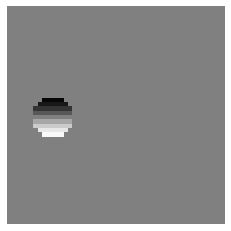

In [10]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 10],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0, np.pi / 2],
    "locations": [[10, 25], [25, 25]],
    "sizes_total": [15],
    "sizes_center": [15 / 50],
    "sizes_surround": [15 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [0],
}

center_cut = CenterSurround(**center_surround_params)

plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

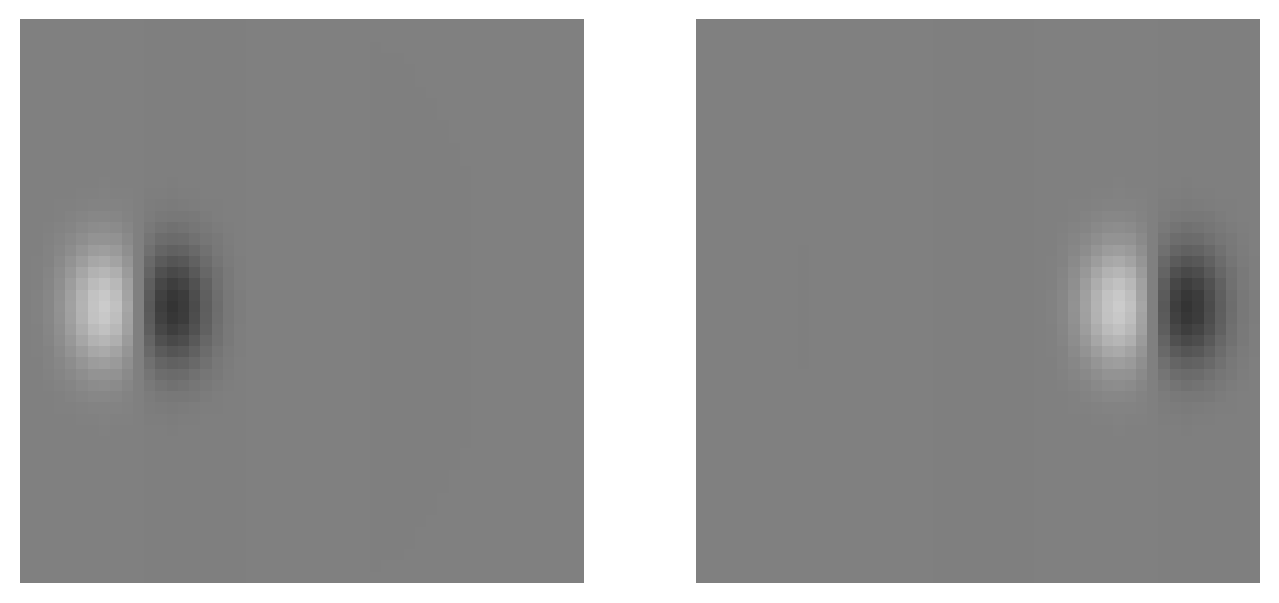

In [43]:
gabor_locations = [(10, 25), (40, 25)]
gabor_params = {
    "canvas_size": [50, 50],
    "sizes": [15],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": gabor_locations,
    "orientations": [0],
    "phases": [np.pi / 2],
    "relative_sf": False,
}


gabor_set = GaborSet(**gabor_params)

fig, axs = plt.subplots(nrows=1, ncols=2, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = gabor_set.images()[idx]
    ax.imshow(gabor, cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")

(-0.5, 49.5, 49.5, -0.5)

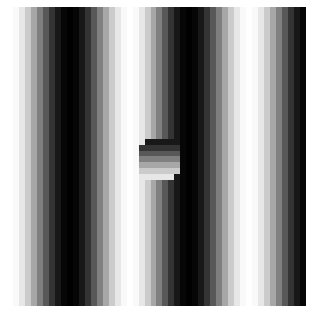

In [46]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_cut = CenterSurround(**center_surround_params)

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask = np.exp(
    -np.sum((XX - np.array([40, 25])) ** 2, axis=-1) / (15 / 4) ** 2 / 2
)

plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

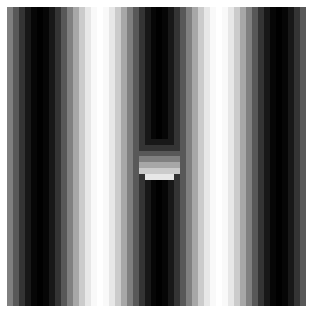

In [48]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 - 40)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_cut = CenterSurround(**center_surround_params)

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask = np.exp(
    -np.sum((XX - np.array([40, 25])) ** 2, axis=-1) / (15 / 4) ** 2 / 2
)

plt.imshow(center_cut.images()[0], cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

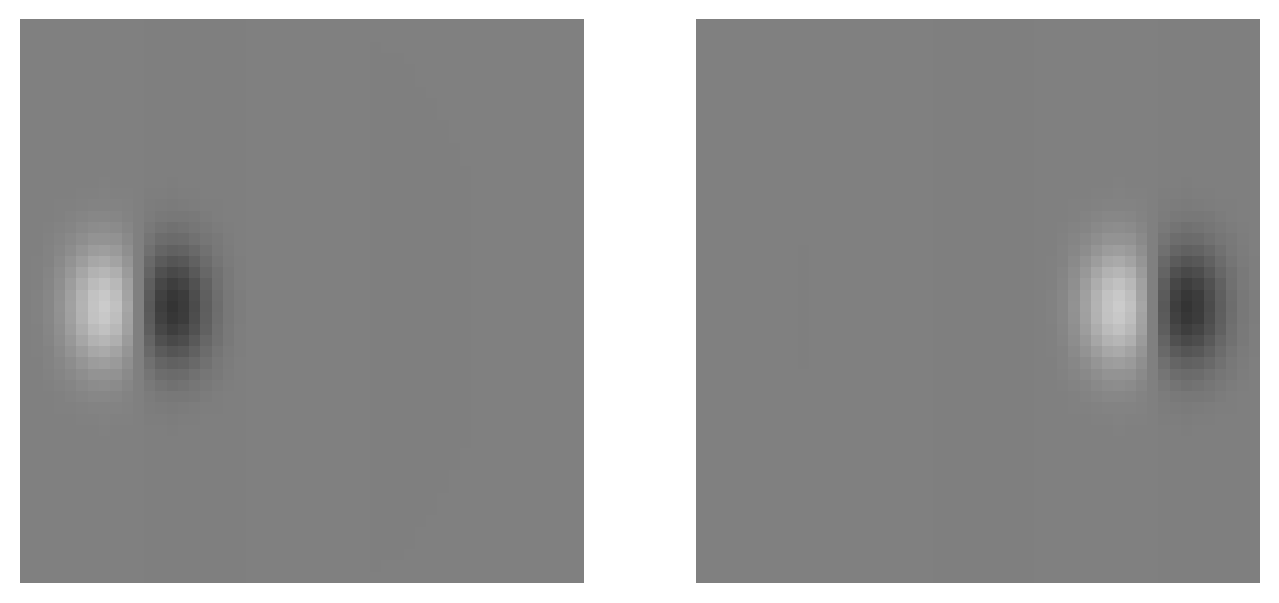

In [49]:
gabor_locations = [(10, 25), (40, 25)]
gabor_params = {
    "canvas_size": [50, 50],
    "sizes": [15],
    "spatial_frequencies": [1 / 20],
    "contrasts": [1.0],
    "grey_levels": [0.0],
    "eccentricities": [0.0],
    "locations": gabor_locations,
    "orientations": [0],
    "phases": [np.pi / 2],
    "relative_sf": False,
}


gabor_set = GaborSet(**gabor_params)

fig, axs = plt.subplots(nrows=1, ncols=2, dpi=200)
for idx, ax in enumerate(axs.ravel()):
    gabor = gabor_set.images()[idx]
    ax.imshow(gabor, cmap="gray", vmin=-1, vmax=1)
    ax.axis("off")

(-0.5, 49.5, 49.5, -0.5)

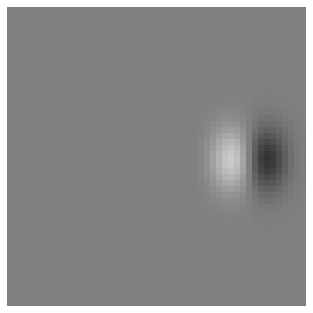

In [50]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 - 40)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_cut = CenterSurround(**center_surround_params)

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask = np.exp(
    -np.sum((XX - np.array([40, 25])) ** 2, axis=-1) / (15 / 4) ** 2 / 2
)

plt.imshow(center_cut.images()[0] * gauss_mask, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

(-0.5, 49.5, 49.5, -0.5)

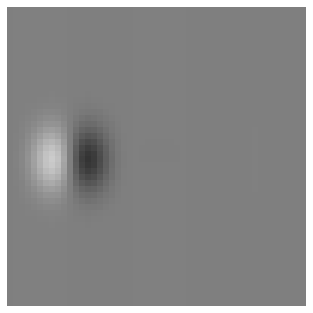

In [53]:
center_surround_params = {
    "canvas_size": gabor_params["canvas_size"],
    "spatial_frequencies_center": gabor_params["spatial_frequencies"],
    "spatial_frequencies_surround": [1 / 20],
    "phases_center": gabor_params["phases"],
    "phases_surround": [np.pi / 2 + 2 * np.pi * 1 / 20 * (25 - 10)],
    "grey_levels": gabor_params["grey_levels"],
    "orientations_center": [np.pi / 2],
    "orientations_surround": [0.0],
    "locations": [[25, 25]],
    "sizes_total": [50],
    "sizes_center": [15 / 4 / 50],
    "sizes_surround": [15 / 4 / 50],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_cut = CenterSurround(**center_surround_params)

U, V = np.meshgrid(np.arange(50), np.arange(50))
XX = np.stack((U, V), axis=-1)
gauss_mask = np.exp(
    -np.sum((XX - np.array([10, 25])) ** 2, axis=-1) / (15 / 4) ** 2 / 2
)

plt.imshow(center_cut.images()[0] * gauss_mask, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")